<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     102 non-null    object 
 1   Branch         102 non-null    object 
 2   City           101 non-null    object 
 3   Customer_Type  102 non-null    object 
 4   Gender         101 non-null    object 
 5   Product_Line   102 non-null    object 
 6   Unit_Price     101 non-null    float64
 7   Quantity       102 non-null    int64  
 8   Total          102 non-null    float64
 9   Payment        102 non-null    object 
 10  Rating         101 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 8.9+ KB
Missing values before cleaning:
Invoice_ID       0
Branch           0
City             1
Customer_Type    0
Gender           1
Product_Line     0
Unit_Price       1
Quantity         0
Total            0
Payment          0
Rating           1
dtype: int64

Missin

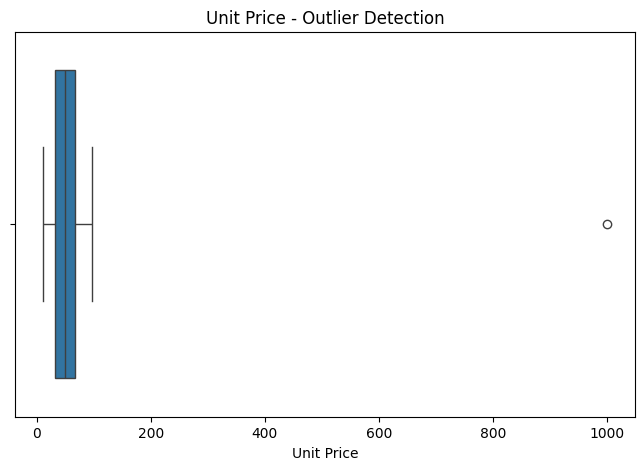

Q1: 31.5225
Q3: 67.0675
IQR: 35.544999999999995
Lower Limit: -21.794999999999995
Upper Limit: 120.38499999999999


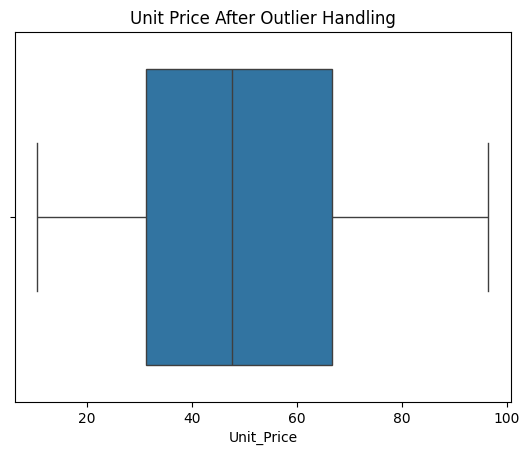

Total Sales: 27588.149999999998
Average Sales: 278.6681818181818
Total Quantity Sold: 528
Product_Line
Electronic accessories    6275.85
Fashion accessories       3052.04
Food and beverages        2645.60
Health and beauty         7959.23
Home and lifestyle        3281.93
Sports and travel         4373.50
Name: Total, dtype: float64


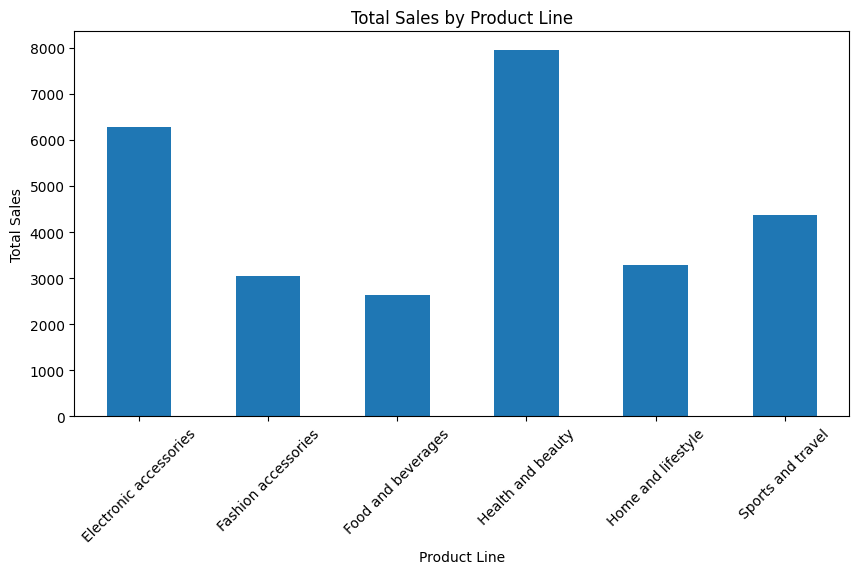

City
Mandalay     9063.28
Naypyitaw    9089.00
Yangon       9435.87
Name: Total, dtype: float64


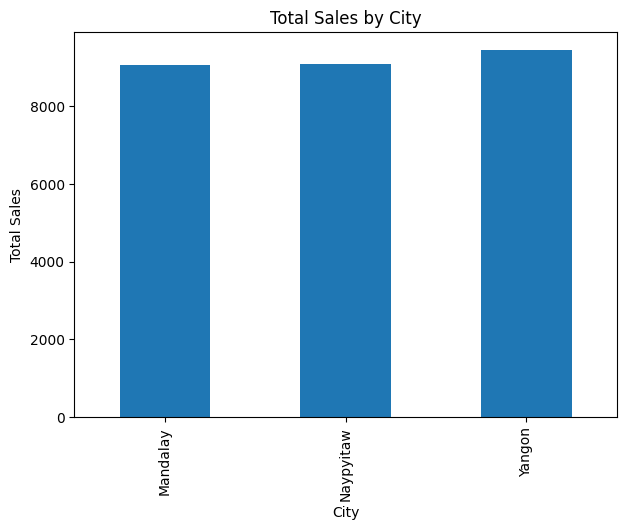

Gender
Female    12238.03
Male      15350.12
Name: Total, dtype: float64


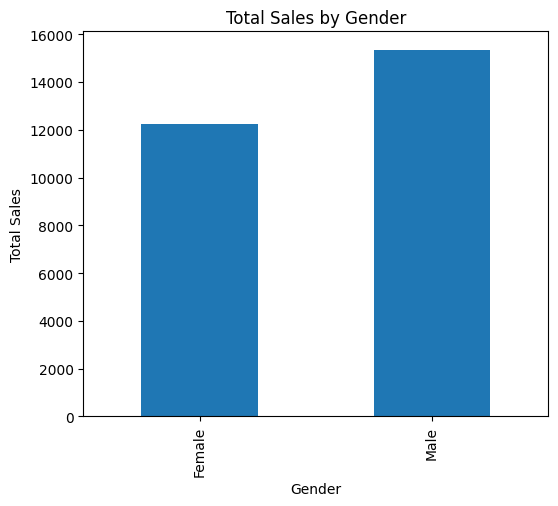

Payment
Cash           36
E-wallet       34
Credit card    28
cash            1
Name: count, dtype: int64


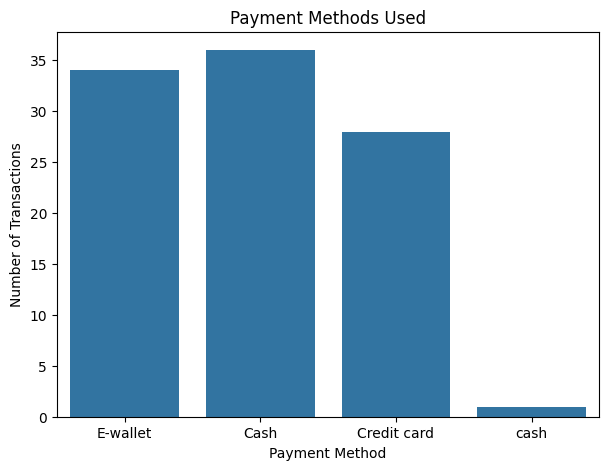

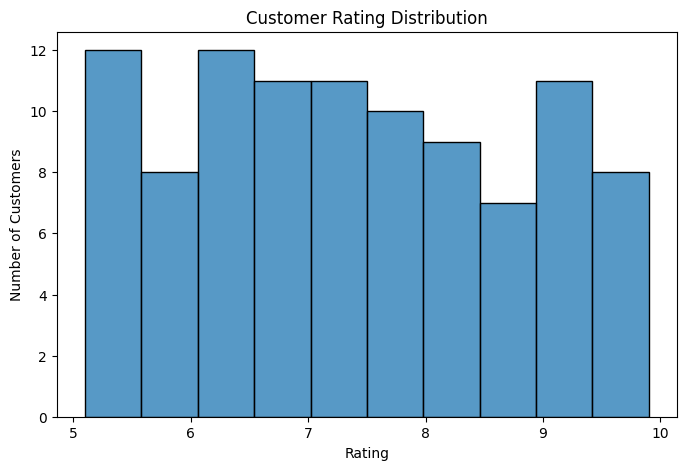

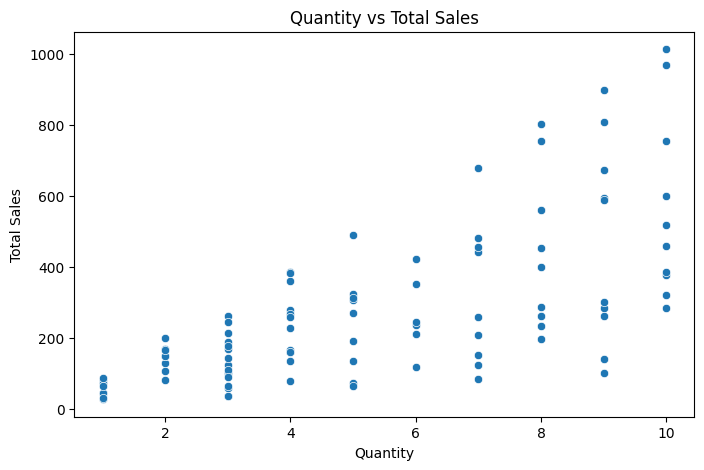

Highest Selling Product: Health and beauty
Sales: 7959.23
Highest Selling City: Yangon
Sales: 9435.87
Most Used Payment Method: Cash
Number of Transactions: 36


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("supermarket_sales_raw.csv")

df.head()
df.shape
df.columns.tolist()
df.info()
df.isnull().sum()
df.describe()
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2)
})

missing
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing values
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

# Check missing values after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

df.duplicated().sum()
df = df.drop_duplicates()
df.shape
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Unit_Price"])

plt.title("Unit Price - Outlier Detection")
plt.xlabel("Unit Price")

plt.show()
Q1 = df["Unit_Price"].quantile(0.25)
Q3 = df["Unit_Price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
outliers = df[
    (df["Unit_Price"] < lower_limit) |
    (df["Unit_Price"] > upper_limit)
]

outliers
df = df[
    (df["Unit_Price"] >= lower_limit) &
    (df["Unit_Price"] <= upper_limit)
]
df.shape
sns.boxplot(x=df["Unit_Price"])

plt.title("Unit Price After Outlier Handling")
plt.show()
total_sales = df["Total"].sum()

print("Total Sales:", total_sales)
average_sales = df["Total"].mean()

print("Average Sales:", average_sales)
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)
sales_by_product = df.groupby("Product_Line")["Total"].sum()

print(sales_by_product)
plt.figure(figsize=(10, 5))

sales_by_product.plot(kind="bar")

plt.title("Total Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()
sales_by_city = df.groupby("City")["Total"].sum()

print(sales_by_city)
plt.figure(figsize=(7, 5))

sales_by_city.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.show()
sales_by_gender = df.groupby("Gender")["Total"].sum()

print(sales_by_gender)
plt.figure(figsize=(6, 5))

sales_by_gender.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()
payment_counts = df["Payment"].value_counts()

print(payment_counts)
plt.figure(figsize=(7, 5))

sns.countplot(x="Payment", data=df)

plt.title("Payment Methods Used")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()
plt.figure(figsize=(8, 5))

sns.histplot(df["Rating"], bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")

plt.show()
plt.figure(figsize=(8, 5))

sns.scatterplot(x="Quantity", y="Total", data=df)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()
highest_product = sales_by_product.idxmax()
highest_product_sales = sales_by_product.max()

print("Highest Selling Product:", highest_product)
print("Sales:", highest_product_sales)
highest_city = sales_by_city.idxmax()
highest_city_sales = sales_by_city.max()

print("Highest Selling City:", highest_city)
print("Sales:", highest_city_sales)
most_used_payment = payment_counts.idxmax()
most_used_payment_count = payment_counts.max()

print("Most Used Payment Method:", most_used_payment)
print("Number of Transactions:", most_used_payment_count)
df.to_csv("supermarket_sales_cleaned.csv", index=False)
df.to_csv("supermarket_sales_cleaned.csv", index=False)